## POLYNOMINAL REGRESSION

## 1. IMPORT LIBRARIES

In [1]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## 2. READ & LOAD CSV FILE

In [2]:
dataset = pd.read_csv("Final_cleaned_realestate_houseprice.csv")

In [3]:
dataset.head()

,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,0.529749,0.904293,1.045104,0.962274,-0.030941,-0.764210,1.266330,1,0,-1.187943,40275084.00
1,-0.170338,-0.437056,0.161028,0.331502,-0.846958,-0.284951,0.375105,1,0,0.828587,26812029.00
2,0.695871,0.233618,0.161028,0.088897,-1.173365,0.366349,0.778754,0,0,0.208116,29315677.00
3,1.660397,0.904293,0.161028,1.010795,-0.928560,-1.255758,0.196594,1,1,-0.567472,46250249.55
4,-0.275436,-0.437056,0.161028,-0.881522,-0.683755,0.722721,-0.436855,0,0,1.138822,17724566.00


## 3. FEATURE AND TARGET VARIABLES ASSIGN

In [4]:
x = dataset[["area_sqft"]]
y = dataset["house_price_inr"]

## 4. TRAING & TESTING SPILTING RECORDS

In [5]:
x_train,x_test,y_train,y_test = train_test_split(x, y, test_size = 0.2, random_state=42)

## [A] TRAING SIZE

In [6]:
len(x_train)

3360

## [B] TESTING SIZE

In [7]:
len(x_test)

840

## 5. CREATE POLYNOMINAL REGRESSION MODEL

In [8]:
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(x_train)
X_test_poly = poly.transform(x_test)

In [9]:

poly_model = LinearRegression()

poly_model.fit(X_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 6. PREDICT NEW house_price_inr FROM THE x_test

In [10]:

y_pred_poly = poly_model.predict(X_test_poly)
y_pred_poly.astype(int)

array([33852864, 27279156, 26742990, 21915181, 30770473, 24348619,
       18729072, 36562092, 27194632, 27953562, 13398522, 12627430,
       27222812, 16009499, 17877524, 24118546, 35161545, 21520449,
       33058574, 32693478, 29209478,  7769428, 27025432, 32707018,
       24032178, 28708457, 35678649, 20875020, 26827781, 25179663,
       31551172, 18967295, 20889719, 35108390, 32300214, 22352589,
       12812808, 20285941, 29722546, 10073962, 22730668, 16508713,
       19130867, 26077072, 38206661, 30907763, 16991360, 27701034,
       38206661, 24463523, 30302652, 32408817, 18952416, 23122298,
       21929782, 25750083, 22628970, 36575230, 19635397, 38206661,
       26275750, 33072077, 11043674, 32761165, 29000937, 17622682,
       19813084, 27307320, 21900580, 16538920, 32693478, 12673793,
       25934993, 15523974,  7467354,  7467354, 20772091, 26091273,
       23527367, 11168411, 22614436, 38206661, 35413730, 21212738,
       38206661,  7467354, 31523855, 29957645,  7467354, 31400

In [11]:
result = pd.DataFrame({
    "Actual_house_price": y_test.values,
    "Predicted_house_price": y_pred_poly.astype(int)
})

print(result)

     Actual_house_price  Predicted_house_price
0            36890986.0               33852864
1            27836840.0               27279156
2            15321534.0               26742990
3            30812774.0               21915181
4            18194835.0               30770473
..                  ...                    ...
835          20918771.0               16795456
836          44375916.0               33543799
837          22099538.0               37387123
838          22898162.0               22352589
839          26744300.0               20064466

[840 rows x 2 columns]


## 7. Calculate Evaluation Metrics

## [A] Mean squared error

In [12]:
mse = mean_squared_error(y_test, y_pred_poly)
print(f"Mean squared error : {mse}")

Mean squared error : 54647096681575.88


Mean Squared Error (MSE) calculates the average of squared errors, giving more importance to larger errors. 

## [B] Mean absolute error

In [13]:
mae = mean_absolute_error(y_test,y_pred_poly)
print(f"Mean absolute error : {mae}")

Mean absolute error : 5822995.297301807


Mean Absolute Error (MAE) measures the average absolute difference between the actual and predicted values.

## [C] Root mean sqaured error

In [14]:
rmse = np.sqrt(mse)
print(f"root mean sqaured error : {rmse}")

root mean sqaured error : 7392367.461211319


 Root Mean Squared Error (RMSE) is the square root of MSE and provides error values in the same units as the target variable.

## [D] R2 Score

In [15]:
r2 = r2_score(y_test,y_pred_poly)
print(f"R2 score : {r2}")

R2 score : 0.5619982981496369


The R² Score indicates the proportion of variance in the target variable that is explained by the model. Adju

In [16]:
accurate_percentage_ = r2 * 100
print(f"Accurate Percentage : {accurate_percentage_}%")

Accurate Percentage : 56.199829814963685%


## [E] Adjusted r2 score

In [17]:
# Number of samples and predictors
n = len(y_test)
p = 1   # simple regression has 1 predictor

Adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"Adjusted r2 score : {Adjusted_r2}")

Adjusted r2 score : 0.5614756230877629


Adjusted R² Score further adjusts the R² value based on the number of predictors used in the model.


## 8. Compare Linear vs Polynomial Visually

In [18]:


linear_model = LinearRegression()

linear_model.fit(x_train, y_train)

y_pred_linear = linear_model.predict(x_test)

## Visualization

c:\Users\hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


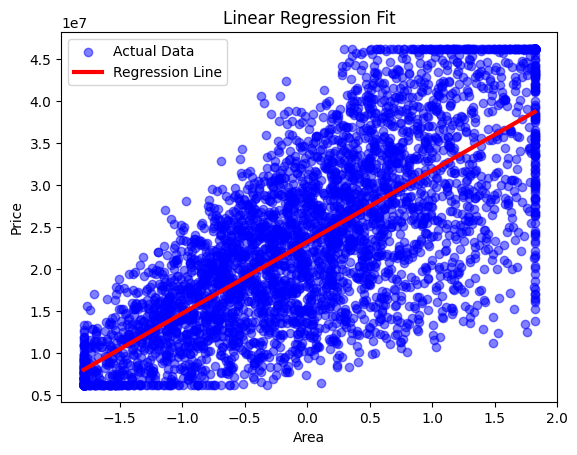

In [19]:


plt.scatter(x, y, color='blue', alpha=0.5, label='Actual Data')


x_min, x_max = np.min(x), np.max(x)
x_line = np.linspace(x_min, x_max, 100).reshape(-1, 1)

y_line = linear_model.predict(x_line)

# 4. Plot regression line
# Added color='red' and linewidth=3 so it stands out clearly from the blue dots
plt.plot(x_line, y_line, color='red', linewidth=3, label='Regression Line')

plt.title("Linear Regression Fit")
plt.xlabel("Area")
plt.ylabel("Price")
plt.legend() # Shows the labels we added above

plt.show()

* **Linear Regression Fit:** A scatter plot with translucent data points overlaid by a straight red line representing a standard linear regression model.

## Polynomial Graph

c:\Users\hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


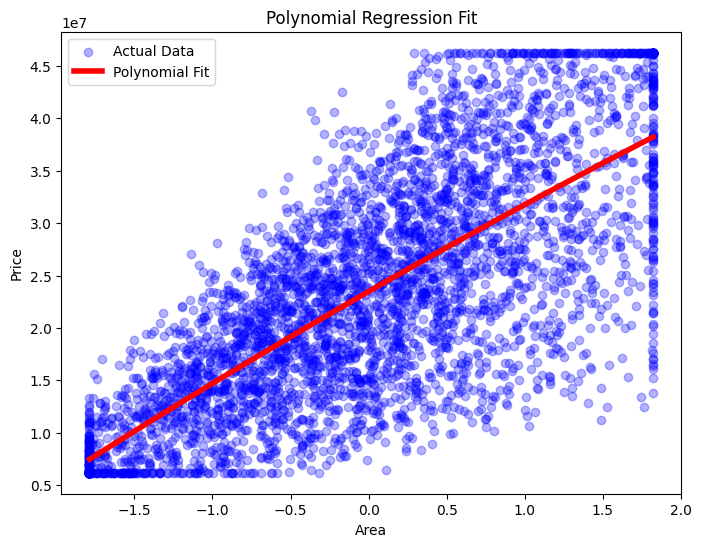

In [20]:
plt.figure(figsize=(8, 6))

plt.scatter(x, y, color='blue', alpha=0.3, label='Actual Data')

# 3. Your correct logic for the smooth curve
X_grid = np.linspace(x.min(), x.max(), 100).reshape(-1,1)
X_grid_poly = poly.transform(X_grid)
y_grid_pred = poly_model.predict(X_grid_poly)

# 4. Plot the curve in a BRIGHT color and make it THICK
plt.plot(X_grid, y_grid_pred, color='red', linewidth=4, label='Polynomial Fit')

plt.title("Polynomial Regression Fit")
plt.xlabel("Area")
plt.ylabel("Price")
plt.legend() # This will add a key so you know what is what

plt.show()

* **Polynomial Regression Fit:** A scatter plot featuring a slightly curved red line representing a polynomial regression model, capturing a bit more nuance in the data's trend.

### 9. Identifying Overfitting and Underfitting

To determine whether a model is performing well or suffering from overfitting or underfitting, we compare the **training score** and **testing score**.

| Case | Training Score | Testing Score | Meaning |
|-----|---------------|--------------|--------|
| Good Model | High | High | The model learns the pattern well and generalizes properly to new data. |
| Overfitting | Very High | Low | The model memorizes the training data but performs poorly on unseen data. |
| Underfitting | Low | Low | The model is too simple and cannot capture the underlying pattern in the data. |

In [21]:
# Training prediction
y_train_pred = poly_model.predict(X_train_poly)

# Training R2
train_r2 = r2_score(y_train, y_train_pred)

# Testing R2
test_r2 = r2_score(y_test, y_pred_poly)

print("Training R2 Score:", train_r2)
print("Testing R2 Score:", test_r2)

Training R2 Score: 0.571186669390245
Testing R2 Score: 0.5619982981496369


Good Model